![erfan.jpg](../image/erfan.jpg)

## **multiple linear regression**

**author : Erfan Rashidi**

Target variable ($Y$):

`btc_price` (Bitcoin price): The quantity the model attempts to estimate based on other factors.

Independent features ($X$):

`volume` (trading volume): Represents the level of liquidity and daily trader 
activity in the market, directly influencing price volatility.

`hash_rate` (network hash rate): Reflects the total processing power and security of the Bitcoin blockchain, serving as a measure of miner activity and stability.

`sma_7` (7-day Simple Moving Average): A widely used technical analysis indicator that smooths out data and tracks the short-term direction and momentum of price trends.

`gold_price` (price of an ounce of gold): A macroeconomic benchmark used to examine the correlation between Bitcoin and traditional safe-haven assets in global markets.

Importing the required libraries.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sklearn.linear_model as lm
from sklearn.metrics import r2_score

we give some data in a dictionary and then convert it to csv file in this cell.

In [27]:
bitcoin_data = {
    'volume': [35.2, 40.1, 38.5, 42.0, 45.3, 39.8, 41.2, 44.5, 48.0, 46.1, 49.2, 51.0],
    'hash_rate': [450, 455, 452, 460, 465, 458, 462, 467, 470, 472, 475, 480],
    'sma_7': [62000, 62500, 62300, 63000, 63800, 63200, 63500, 64100, 64800, 64500, 65200, 65900],
    'gold_price': [2300, 2310, 2305, 2320, 2330, 2315, 2325, 2335, 2340, 2338, 2345, 2350],
    'btc_price': [63000, 63400, 63100, 64200, 65000, 63900, 64300, 65200, 66000, 65800, 66500, 67200],
}
df = pd.DataFrame(bitcoin_data)

df.to_csv("bitcoin_data.csv", index=False)

so we plot btc price based on volume, hash rate, sma_7, gold price one by one.

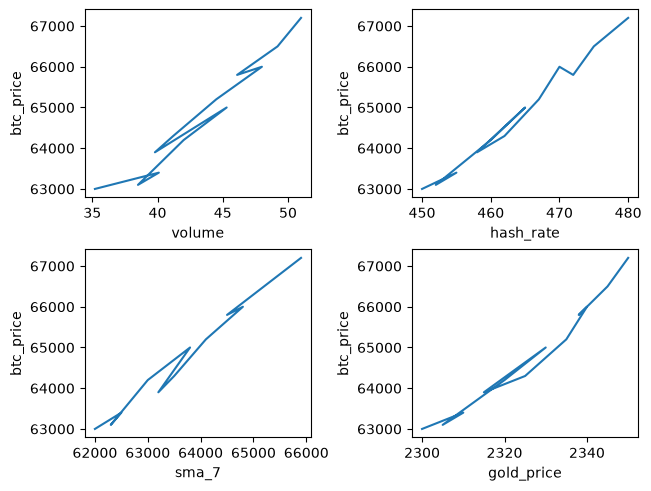

In [28]:
cdf = pd.read_csv("bitcoin_data.csv")

def show(ax, cdf, feature):
    ax.plot(cdf[feature], cdf["btc_price"])
    ax.set_xlabel(feature)
    ax.set_ylabel("btc_price")

fig, axs = plt.subplots(2, 2, layout="constrained")

for ax in axs.flat:
    if ax == axs.flat[0]:
        show(ax ,cdf, "volume")
    elif ax == axs.flat[1]:
        show(ax, cdf, "hash_rate")
    elif ax == axs.flat[2]:
        show(ax, cdf, "sma_7")
    elif ax == axs.flat[3]:
        show(ax, cdf, "gold_price")

in this cell we divide the data into train and test data. we use 80% of the data for training and 20% for testing.

In [29]:
train_x, test_x, train_y, test_y = train_test_split(cdf[["volume", "hash_rate", "sma_7", "gold_price"]], cdf[["btc_price"]], test_size=0.2, random_state=42)

this cell for training the model and finding the coefficient and intercept of the multiple linear regression model.

In [30]:
model = lm.LinearRegression()
model.fit(train_x, train_y)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[103.25250442  39.57560979   0.42882701   4.07164372]]
Intercept: [5113.24910534]


and in the end we show degree of correspondence our mechine with Actual value.

In [31]:
test_model = model.predict(test_x)
print("R2_score:", r2_score(test_y, test_model))

R2_score: 0.9641511297654393


Which has a match rate of over 96%.